In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_digits

X, y = load_digits(return_X_y=True)

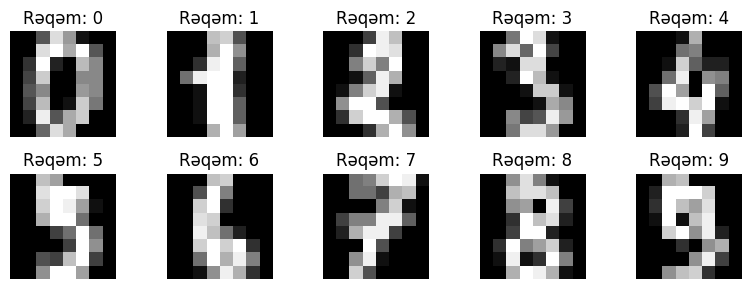

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(8, 3))

for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(8, 8), cmap="gray")
    ax.set_title(f"Rəqəm: {y[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X)

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 16)
scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_pca)

    score = silhouette_score(X_pca, labels)
    scores.append(score)

    print(f"k = {k}, Silhouette Score = {score:.4f}")

k = 2, Silhouette Score = 0.1246
k = 3, Silhouette Score = 0.1331
k = 4, Silhouette Score = 0.1356
k = 5, Silhouette Score = 0.1448
k = 6, Silhouette Score = 0.1619
k = 7, Silhouette Score = 0.1702
k = 8, Silhouette Score = 0.1904
k = 9, Silhouette Score = 0.2016
k = 10, Silhouette Score = 0.1948
k = 11, Silhouette Score = 0.1957
k = 12, Silhouette Score = 0.1988
k = 13, Silhouette Score = 0.1943
k = 14, Silhouette Score = 0.1963
k = 15, Silhouette Score = 0.1954


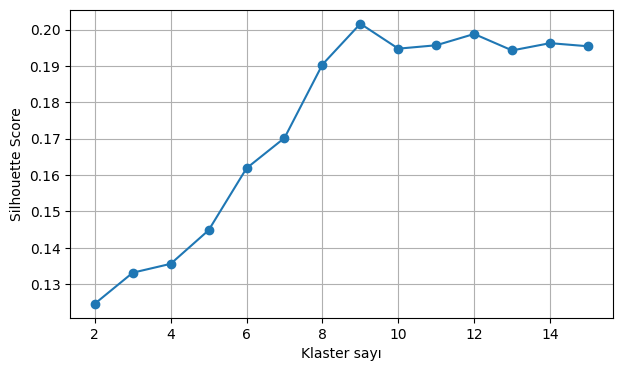

In [6]:
plt.figure(figsize=(7,4))
plt.plot(k_values, scores, marker="o")
plt.xlabel("Klaster sayı")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

In [7]:
best_k = k_values[np.argmax(scores)]
print("Ən yaxşı k:", best_k)

Ən yaxşı k: 9


In [8]:
best_model = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

labels = best_model.fit_predict(X_pca)


Klaster 0


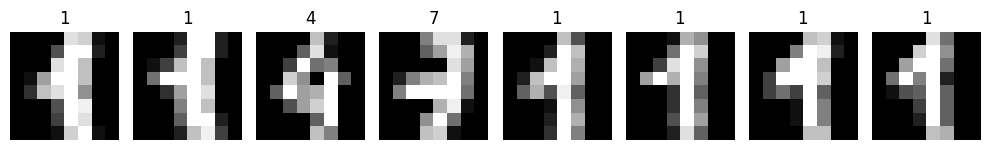


Klaster 1


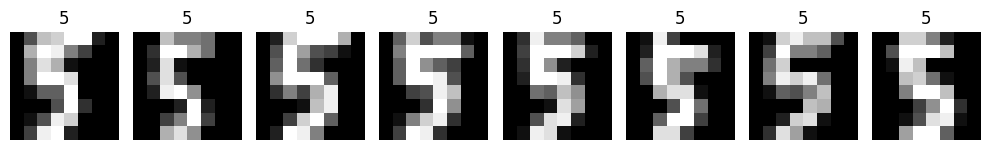


Klaster 2


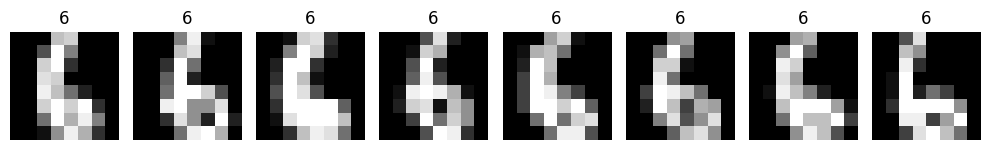


Klaster 3


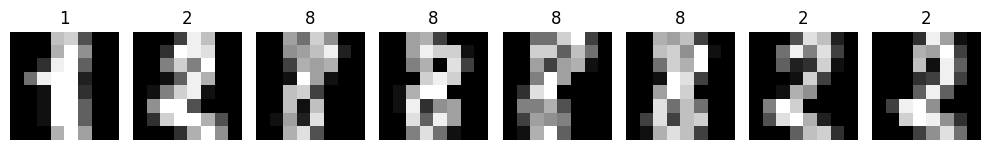


Klaster 4


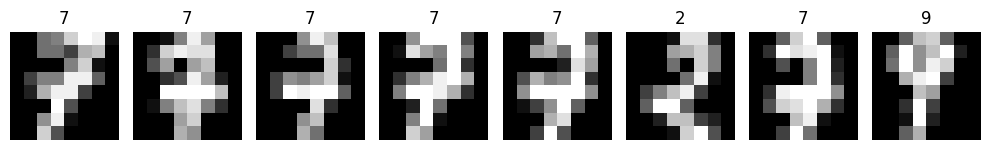


Klaster 5


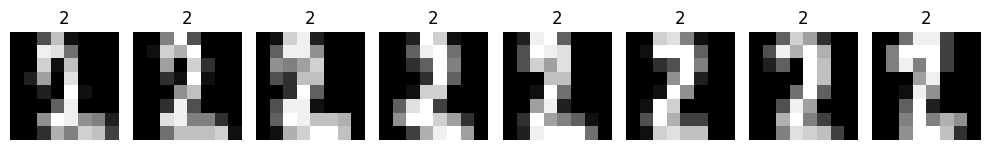


Klaster 6


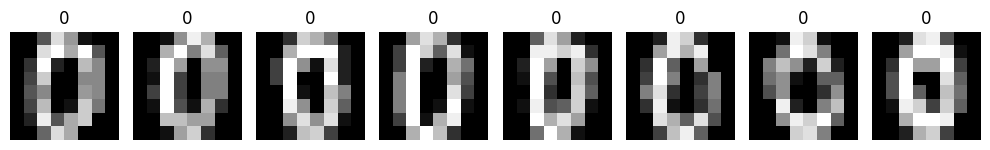


Klaster 7


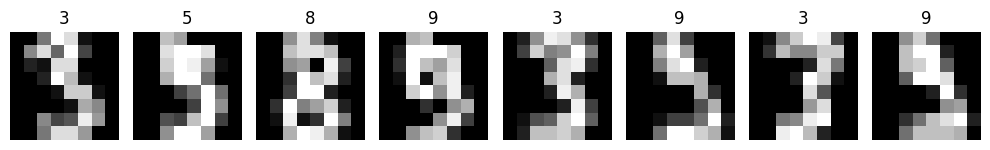


Klaster 8


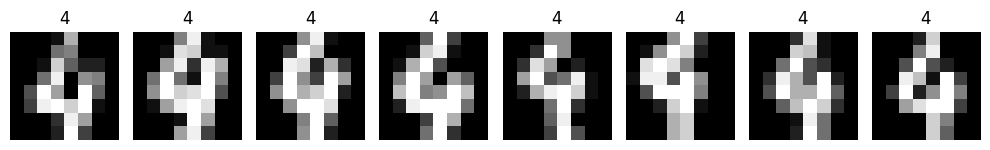

In [9]:
for cluster in range(best_k):

    print(f"\nKlaster {cluster}")

    cluster_images = X[labels == cluster]
    cluster_labels = y[labels == cluster]

    fig, axes = plt.subplots(1, 8, figsize=(10,2))

    for i, ax in enumerate(axes):
        if i < len(cluster_images):
            ax.imshow(cluster_images[i].reshape(8,8), cmap="gray")
            ax.set_title(cluster_labels[i])
        ax.axis("off")

    plt.tight_layout()
    plt.show()